In [2]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import dabest
import osar
from datetime import datetime


date = datetime.today().strftime('%Y%m%d')
#NOTE: SUPPRESSES WARNINGS!

import warnings

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="default", category=UserWarning)

print(osar.__version__)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:01<00:00, 10.74it/s]

Numba compilation complete!
0.23.9


In [3]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = homecomp


#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager
import matplotlib as mpl

font_dirs = ["fonts"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

availablefonts = [f.name for f in mpl.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

## Code

In [4]:
normal_path = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\DATA\OSAR"
#reverse_path = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\DATA\OSAR_other"
reversal = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\DATA\OSAR_other\other"

In [5]:
normal_acr = osar.osar(normal_path + r"\VT999036 x ACR", driver="VT999036")
normal_chrimson = osar.osar(normal_path + r"\VT999036 x Chrimson2", driver="VT999036")
reverse_acr = osar.osar(reversal + r"\VT999036[Reverse] x ACR", driver="VT999036[Reverse]")
reverse_chrimson = osar.osar(reversal + r"\VT999036[Reverse] x Chrimson2", driver="VT999036[Reverse]")


Creating borders for each fly...
Done.

Processing CSV 31 of 31
Summarising results for all flies...
All done.
Creating borders for each fly...
Done.

Processing CSV 40 of 40
Summarising results for all flies...
All done.
Creating borders for each fly...
Done.

Processing CSV 24 of 24
Summarising results for all flies...
All done.
Creating borders for each fly...
Done.

Processing CSV 24 of 24
Summarising results for all flies...
All done.


In [6]:
def contrastplot_calculation(df):
    osaranalysis = df.contrasts.pi.time_spent_in_light(epoch='first', baseline_corrected=False)
    
    return osaranalysis

In [7]:
normal_acr_plot = contrastplot_calculation(normal_acr)
normal_chrimson_plot = contrastplot_calculation(normal_chrimson)
reverse_acr_plot = contrastplot_calculation(reverse_acr)
reverse_chrimson_plot = contrastplot_calculation(reverse_chrimson)

In [27]:
def format_dabest_subplot(raw_ax, results_df, light_labels=['Eighth', 'Quarter', 'Half', 'Full']):
    n_values = []
    for i in range(len(results_df)):
        n_values.append((results_df.loc[i, 'control_N'], results_df.loc[i, 'test_N']))
    
    xlabels = []
    for ctrl_n, test_n in n_values:
        xlabels.append(f"Control\n(N={ctrl_n})")
        xlabels.append(f"Test\n(N={test_n})")
    
    raw_ax.set_xticklabels(xlabels, fontsize=10)
    contrast_ax = raw_ax.contrast_axes
    contrast_ax.spines['bottom'].set_visible(False)
    contrast_ax.set_xticks([0.5, 2.5, 4.5, 6.5])
    contrast_ax.set_xticklabels(light_labels, fontsize=10)

c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 2.2% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 11.7% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 6.7% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 1.8% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 25.0% of the points cannot be placed. You mi

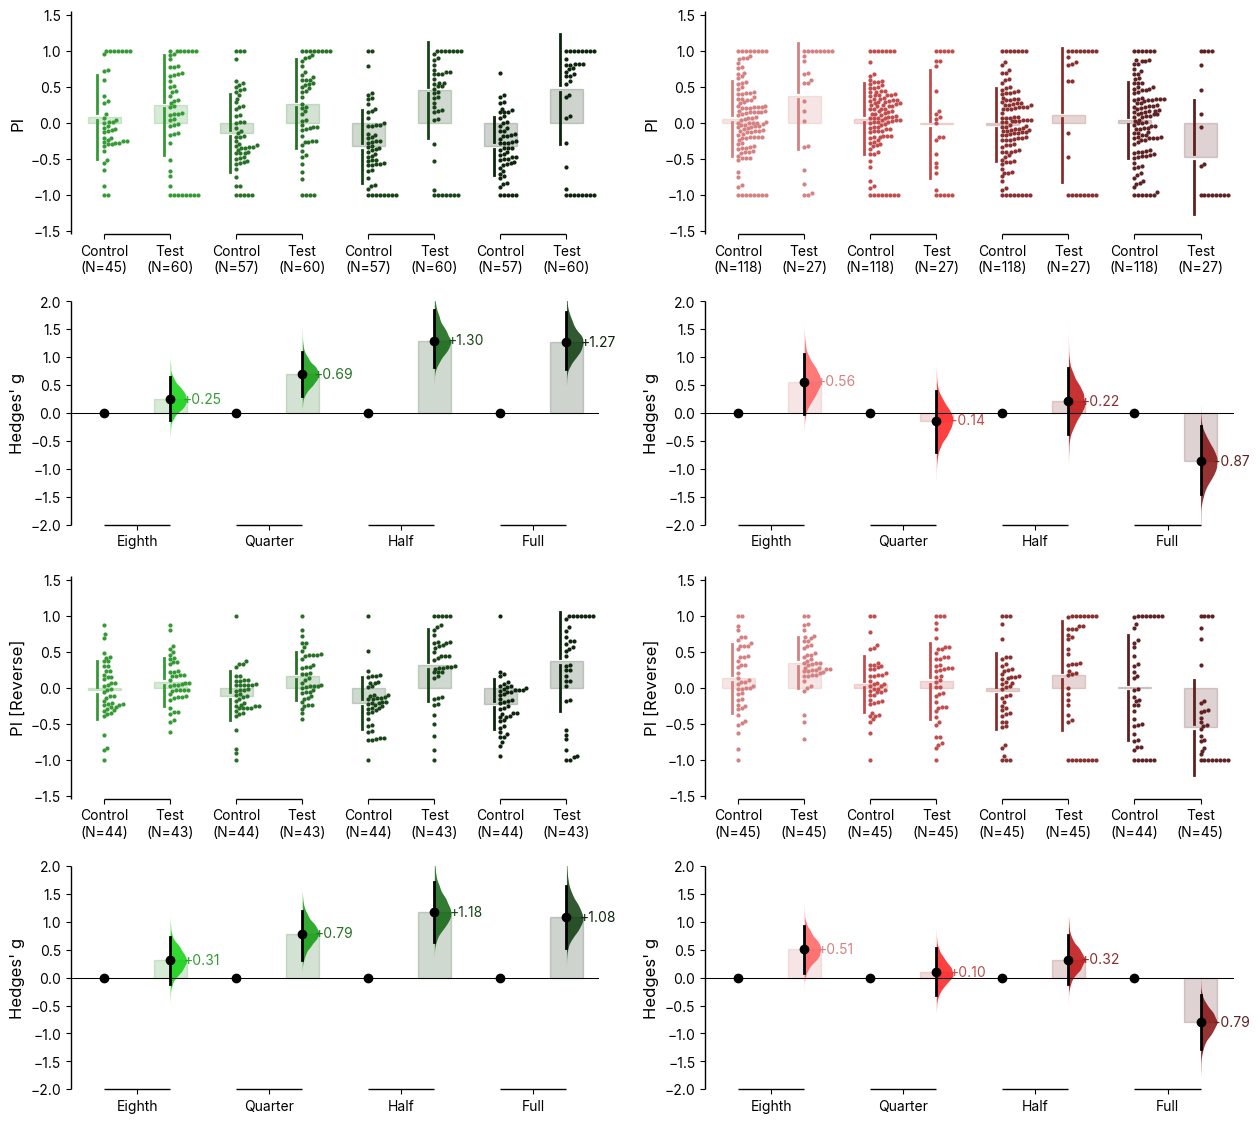

In [33]:
mpl.rcParams['svg.fonttype'] = 'none'


from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(15, 14))

gs = GridSpec(2, 2, figure=fig, hspace=0.1, wspace=0.2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

acrcolormap = ["#00CF00", "#00CF00", "#009600", "#009600", "#005A00", "#005A00", "#003000", "#003000"]
chrcolormap = ["#FF5757", "#FF5757", "#FF1010","#FF1010", "#B90000", "#B90000","#7E0000", "#7E0000"]


plot1 = normal_acr_plot.hedges_g.plot(fontsize_rawylabel=12, fontsize_rawxlabel=8, fontsize_contrastxlabel=12, fontsize_contrastylabel=12, 
                         contrast_marker_size=6, raw_ylim=(-1.55, 1.55), custom_palette=acrcolormap,
                         contrast_ylim=(-2, 2), raw_label="PI",
                         contrast_label="Hedges' g",
                         raw_marker_size=1, ax=ax1)

results1 = normal_acr_plot.hedges_g.results
format_dabest_subplot(ax1, results1)



plot2 = normal_chrimson_plot.hedges_g.plot(fontsize_rawylabel=12, fontsize_rawxlabel=8, fontsize_contrastxlabel=12, fontsize_contrastylabel=12, 
                         contrast_marker_size=6, raw_ylim=(-1.55, 1.55), custom_palette=chrcolormap,
                         contrast_ylim=(-2, 2), raw_label="PI",
                         contrast_label="Hedges' g",
                         raw_marker_size=1, ax=ax2)

results2 = normal_chrimson_plot.hedges_g.results
format_dabest_subplot(ax2, results2)

plot3 = reverse_acr_plot.hedges_g.plot(fontsize_rawylabel=12, fontsize_rawxlabel=8, fontsize_contrastxlabel=12, fontsize_contrastylabel=12, 
                         contrast_marker_size=6, raw_ylim=(-1.55, 1.55), custom_palette=acrcolormap,
                         contrast_ylim=(-2, 2), raw_label="PI [Reverse]",
                         contrast_label="Hedges' g",
                         raw_marker_size=1, ax=ax3)

results3 = reverse_acr_plot.hedges_g.results
format_dabest_subplot(ax3, results3)


plot4 = reverse_chrimson_plot.hedges_g.plot(fontsize_rawylabel=12, fontsize_rawxlabel=8, fontsize_contrastxlabel=12, fontsize_contrastylabel=12, 
                         contrast_marker_size=6, raw_ylim=(-1.55, 1.55), custom_palette=chrcolormap,
                         contrast_ylim=(-2, 2), raw_label="PI [Reverse]",
                         contrast_label="Hedges' g",
                         raw_marker_size=1, ax=ax4)

results4 = reverse_chrimson_plot.hedges_g.results
format_dabest_subplot(ax4, results4)

fig.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\" + date + "_reverseorder.svg")